In [2]:
! pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9

In [3]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import display, Image
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="TafTnLjXkvLUpxGZP8JU")
project = rf.workspace("id-card-vf1zl").project("crop-idcard")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crop-IDCard-3 in yolov11:: 100%|██████████| 4812/4812 [00:01<00:00, 3808.14it/s]


In [5]:
!yolo task=segment mode=train model=yolo11n-seg.pt data={dataset.location}/data.yaml epochs=30 imgsz=640

100% 5.90M/5.90M [00:00<00:00, 156MB/s]
Ultralytics 8.3.100 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=/content/Crop-IDCard-3/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

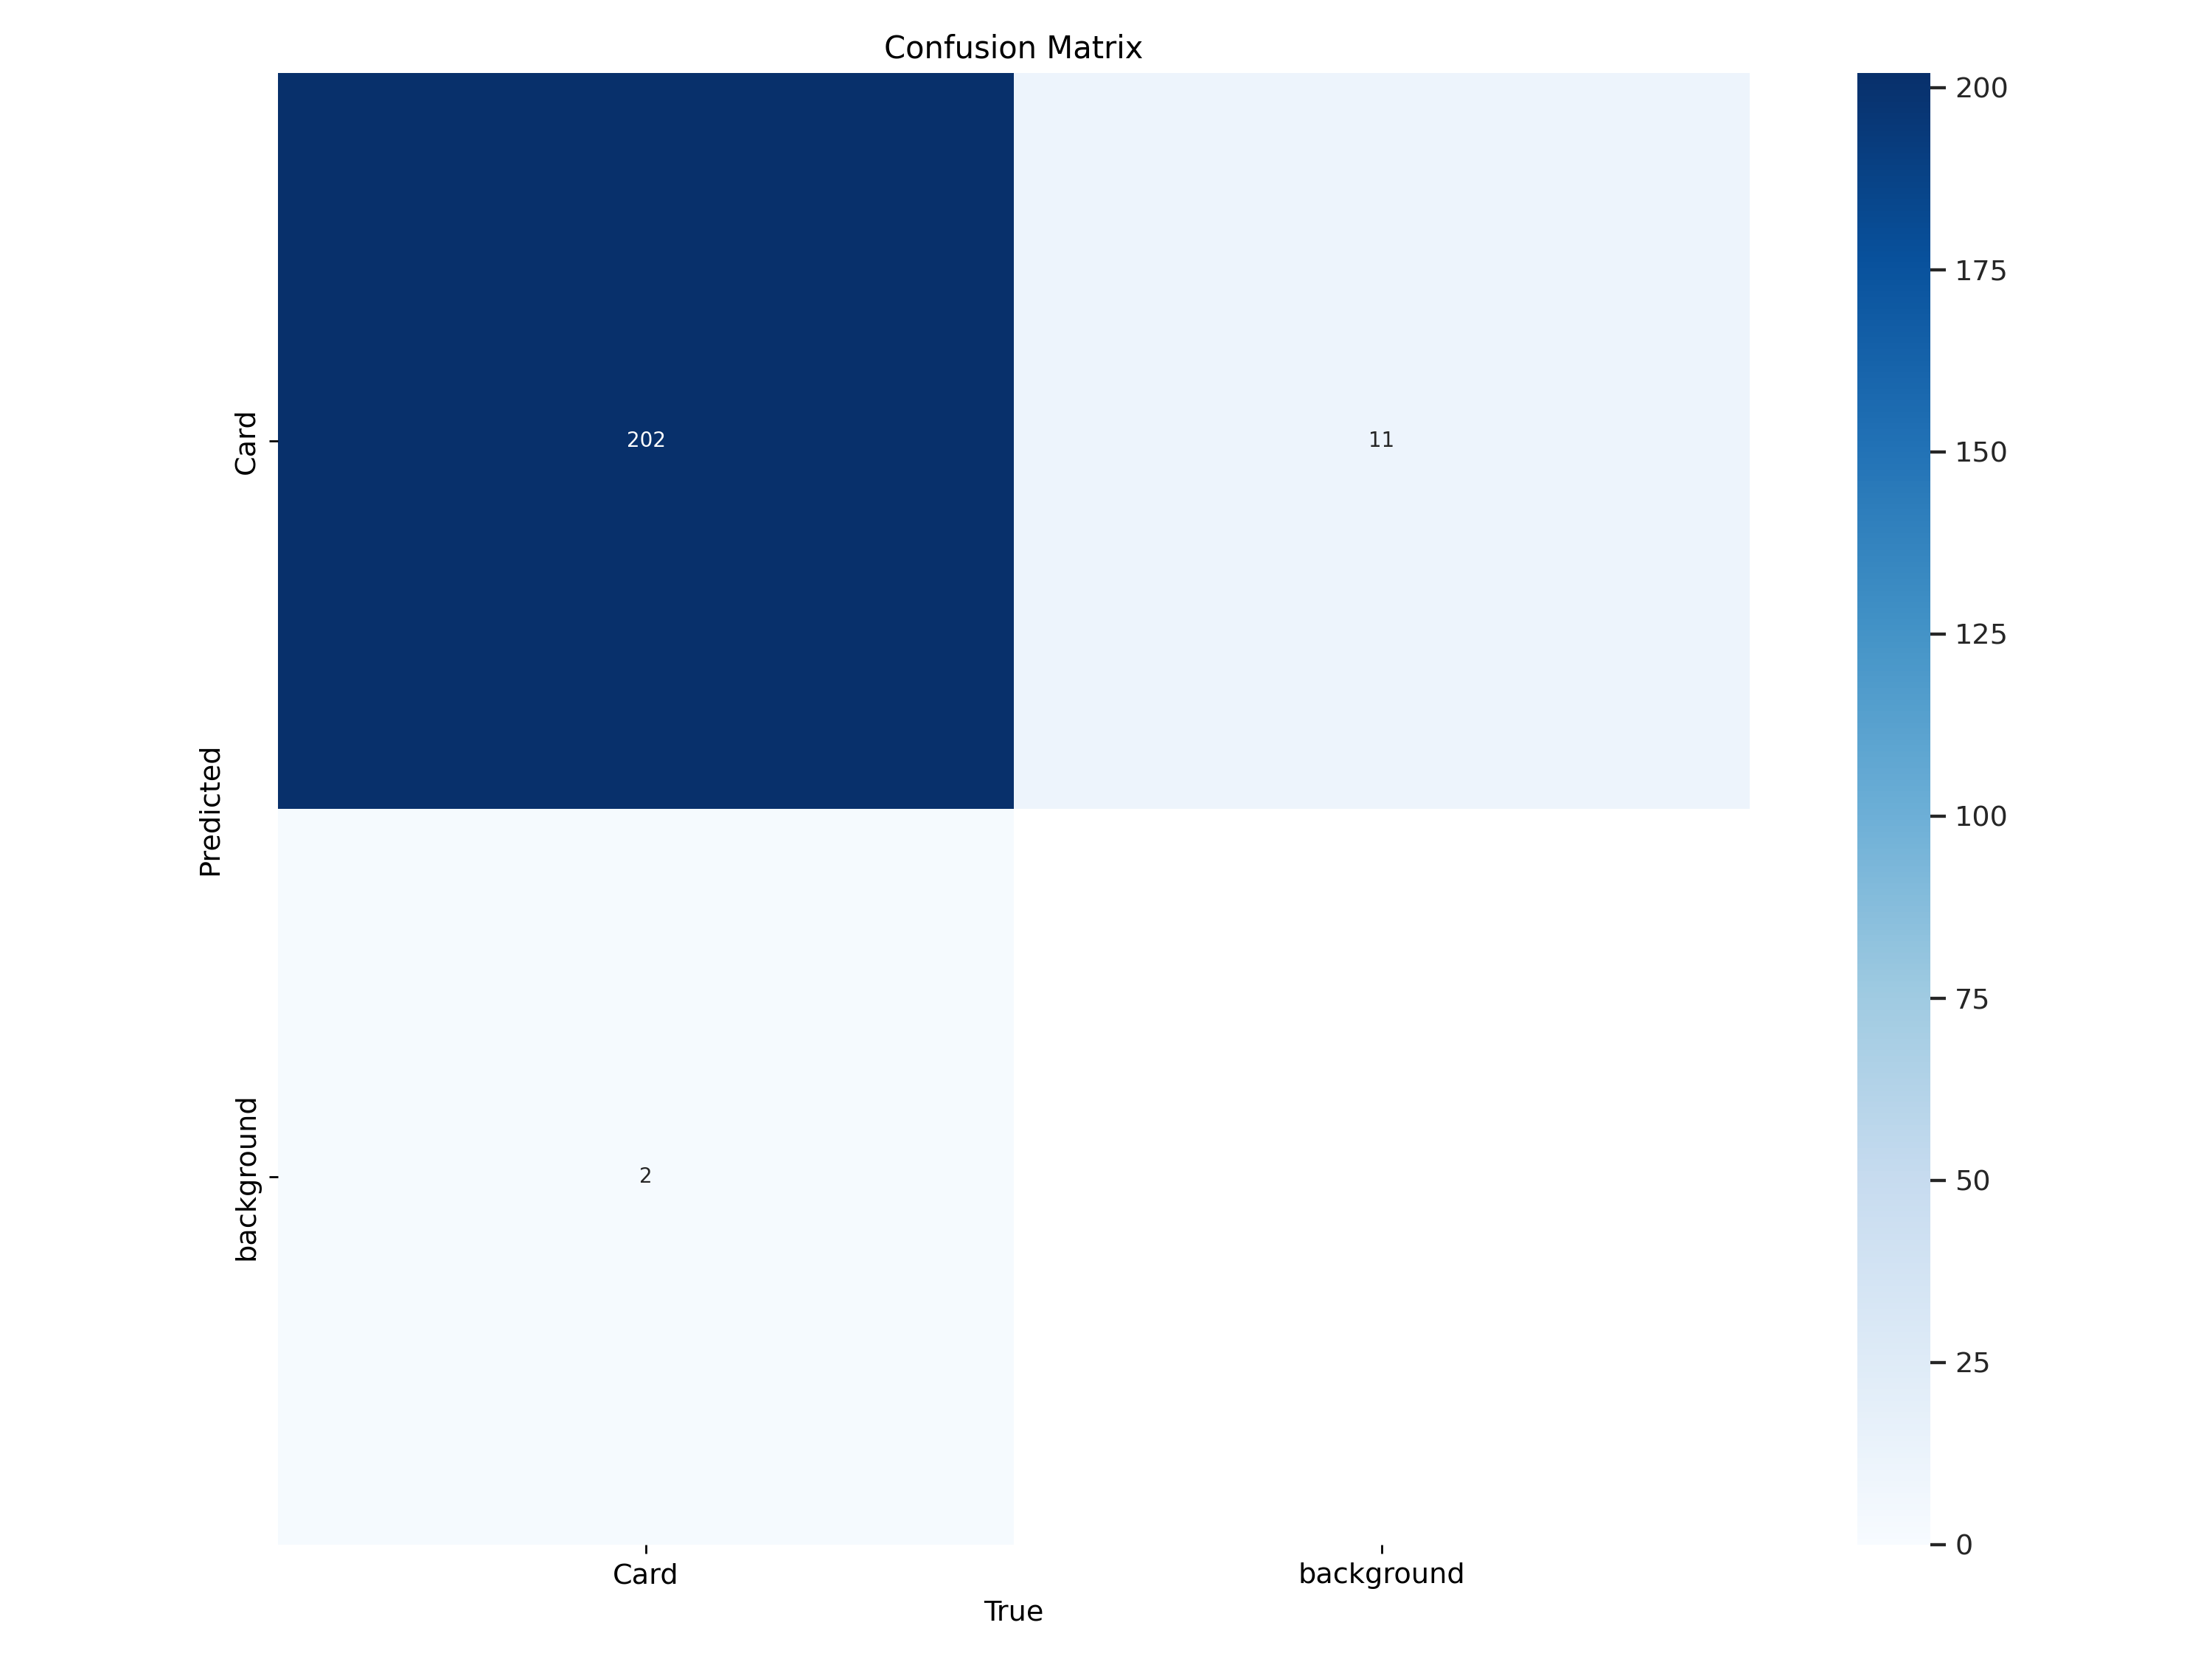

In [7]:
Image(filename=f'runs/segment/train/confusion_matrix.png', width=600)


In [9]:
!yolo task=segment mode=predict model=/content/runs/segment/train/weights/best.pt conf=0.25 source={dataset.location}/test/images

Ultralytics 8.3.100 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 10.2 GFLOPs

image 1/100 /content/Crop-IDCard-3/test/images/111_jpg.rf.b08261c4adedc93724a66837dd28ce6f.jpg: 640x640 1 Card, 11.2ms
image 2/100 /content/Crop-IDCard-3/test/images/123_jpg.rf.cc654a62744e7efde178dfbea4361c24.jpg: 640x640 1 Card, 10.7ms
image 3/100 /content/Crop-IDCard-3/test/images/129_jpg.rf.3e39563ce65f9056008e521ce247bf46.jpg: 640x640 1 Card, 10.4ms
image 4/100 /content/Crop-IDCard-3/test/images/12_jpg.rf.16b5124ed76ef4a0598b4d5ff63b5322.jpg: 640x640 1 Card, 9.9ms
image 5/100 /content/Crop-IDCard-3/test/images/140_jpg.rf.cc568295adba7b97b32e1c3af4d11be2.jpg: 640x640 1 Card, 9.9ms
image 6/100 /content/Crop-IDCard-3/test/images/148_jpg.rf.b9370db4115fd3b5dbe79a66c55e9d16.jpg: 640x640 3 Cards, 10.1ms
image 7/100 /content/Crop-IDCard-3/test/images/152_jpg.rf.2cda7b8f8c43520895699123ba4ff035.jpg: 640x640 1 Card, 9.8m

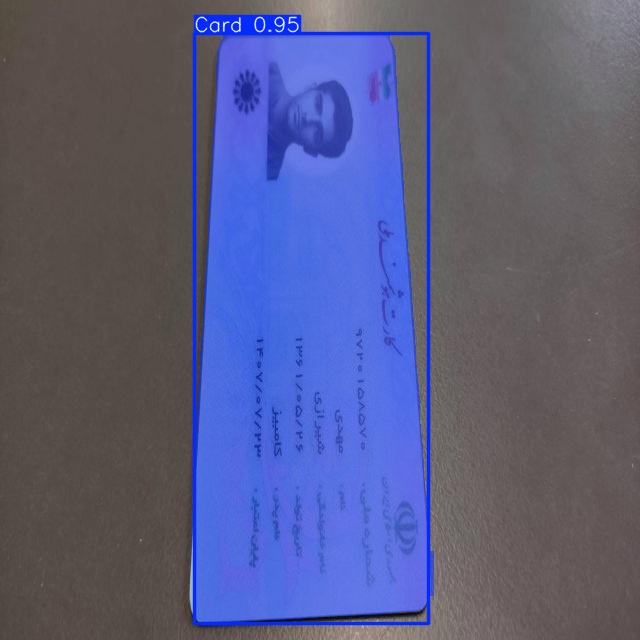

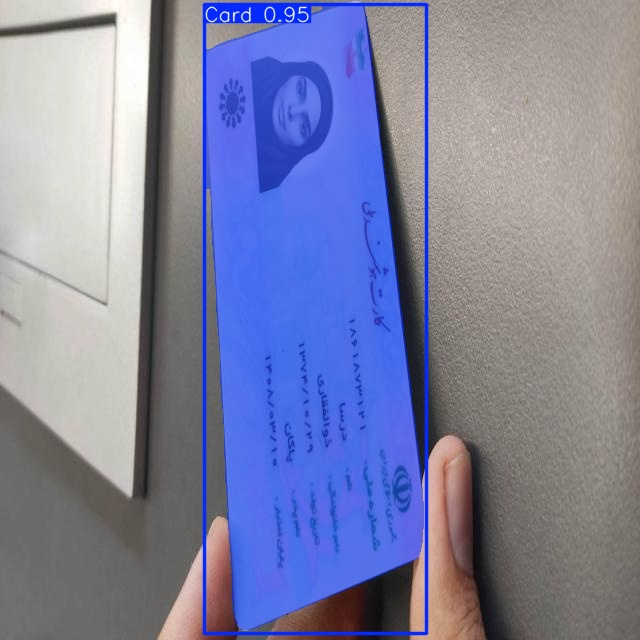

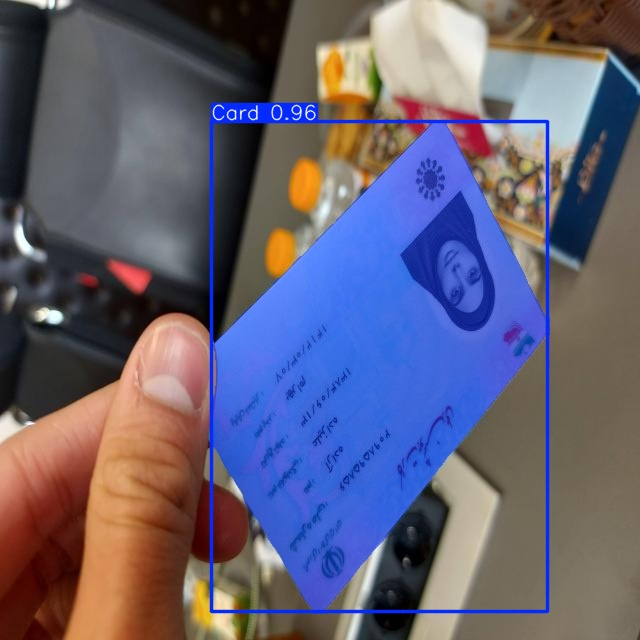

In [12]:
import glob
from IPython.display import display, Image

for img in glob.glob(f'runs/segment/predict/*.jpg')[:3]:
  display(Image(filename=img, height=600))
  print('\n')

In [21]:
!git clone https://github.com/cactus1386/NationalCard-ImageProccessing.git

Cloning into 'NationalCard-ImageProccessing'...
remote: Enumerating objects: 533, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 533 (delta 52), reused 14 (delta 8), pack-reused 432 (from 2)
Receiving objects: 100% (533/533), 165.51 MiB | 16.95 MiB/s, done.
Resolving deltas: 100% (141/141), done.



0: 288x640 1 Card, 14.5ms
Speed: 2.1ms preprocess, 14.5ms inference, 2.4ms postprocess per image at shape (1, 3, 288, 640)


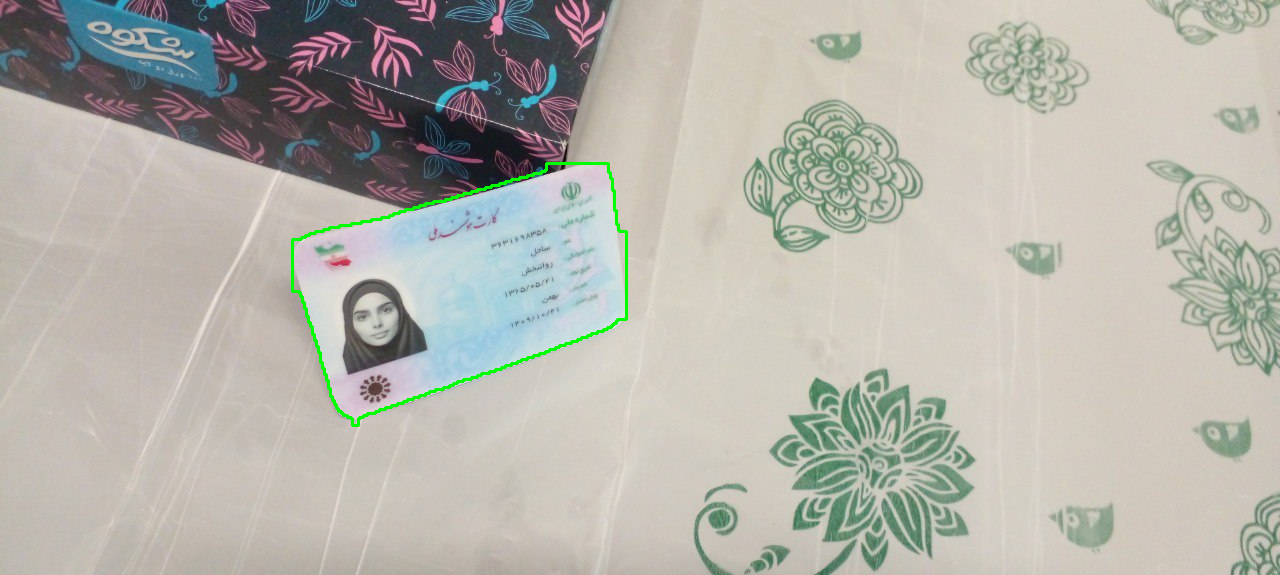

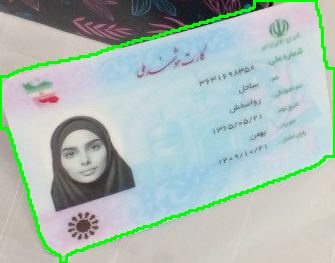

In [22]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
# Load your YOLO model
model = YOLO("/content/NationalCard-ImageProccessing/weight/card_segmentation.pt")  # Replace with your model path

# Load your image
image = cv2.imread("/content/IMG_20250313_224003_750.jpg")

# Perform inference
results = model(image)

# Process results
for r in results:
    masks = r.masks  # Access the segmentation masks
    if masks is not None:
        for mask in masks.xy:  # Get the mask coordinates (list of points)
            # 'mask' is a numpy array containing the (x, y) coordinates of the mask
            # Now you have the coordinates of the blue part (the segmentation mask)

            pts = mask.astype(int)
        # Find the bounding rectangle of the contour
            x, y, w, h = cv2.boundingRect(pts)

            # Crop the image using the bounding rectangle coordinates
            cropped_image = image[y:y+h, x:x+w]
            cv2.polylines(image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
            cv2_imshow(image)
            cv2_imshow(cropped_image)
# Display or save the image with the mask outline (optional)
